# SMS Spam Detection Notebook (Very Simple Step-by-Step)

This notebook is written in a very simple style.

How to use it:
- Run one cell at a time from top to bottom.
- Read every output before going to the next cell.
- If one step fails, fix that step first.

Goal: predict whether an SMS message is `spam` or `ham`.

## Step 0: Import Libraries

What is happening here:
- We import all tools needed for data work, plotting, and deep learning.
- We set fixed random seeds so results stay more repeatable.

Why this step matters:
- Without libraries, the notebook cannot run.
- Fixed seeds help beginners compare results more fairly.

In [86]:
# Cell 3: Optional install command if packages are missing.
# Run this only if the next import cell fails.
# %pip install numpy pandas scikit-learn matplotlib seaborn wordcloud tensorflow

In [87]:
# Cell 4: Import libraries and set random seeds.
from pathlib import Path
import string
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from wordcloud import WordCloud

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

STOP_WORDS = set(ENGLISH_STOP_WORDS)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 1: Find and Load the SMS CSV

What is happening here:
- We search common folders for the SMS CSV file.
- We load the file into a pandas DataFrame.
- We support either `label` and `text` columns or the common raw SMS columns `v1` and `v2`.

Why this step matters:
- Many beginner datasets come with different column names.
- This step makes the notebook easier to reuse.

In [88]:
# Cell 6: Locate the SMS CSV and load it.
possible_paths = [
    Path.cwd() / 'data' / 'raw' / 'spam.csv',
    Path.cwd().parent / 'data' / 'raw' / 'spam.csv',
    Path.cwd() / 'spam.csv',
    Path.cwd().parent / 'spam.csv',
]

for path in possible_paths:
    if path.exists():
        csv_path = path
        break
else:
    raise FileNotFoundError("Could not find spam.csv in the project root or data/raw/.")

raw_data = pd.read_csv(csv_path, encoding='latin-1')
print(f'Loaded file: {csv_path}')
print(f'Shape: {raw_data.shape}')
raw_data.head()

Loaded file: /Users/bti-001541/machine-learning-project/data/raw/spam.csv
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Step 2: Clean the Table Structure and Rename Columns

What is happening here:
- If the file uses `v1` and `v2`, we rename them to `label` and `text`.
- We drop empty helper columns like `Unnamed: 2`.
- We keep only the two columns we need.

Why this step matters:
- A clean table is easier to understand.
- Later cells become simpler because the column names stay consistent.

In [89]:
# Cell 8: Rename columns into a simple format.
if {'label', 'text'}.issubset(raw_data.columns):
    sms_data = raw_data[['label', 'text']].copy()
elif {'v1', 'v2'}.issubset(raw_data.columns):
    sms_data = raw_data.copy()
    drop_columns = [column for column in ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'] if column in sms_data.columns]
    if drop_columns:
        sms_data = sms_data.drop(columns=drop_columns)
    sms_data = sms_data.rename(columns={'v1': 'label', 'v2': 'text'})
    sms_data = sms_data[['label', 'text']].copy()
else:
    raise ValueError('Expected columns either [label, text] or [v1, v2].')

sms_data = sms_data.dropna(subset=['label', 'text']).reset_index(drop=True)
sms_data['label'] = sms_data['label'].astype(str).str.strip().str.lower()
sms_data['text'] = sms_data['text'].astype(str)
sms_data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3: Balance the Dataset

What is happening here:
- We first plot the **original** (unbalanced) distribution so you can see the problem.
- We keep all spam rows.
- We randomly sample the same number of ham rows.
- Then we shuffle the rows.

Why this step matters:
- The original dataset has far more ham than spam — this biases the model.
- Balanced classes make training fairer.
- Accuracy becomes more meaningful for both classes.

Original shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


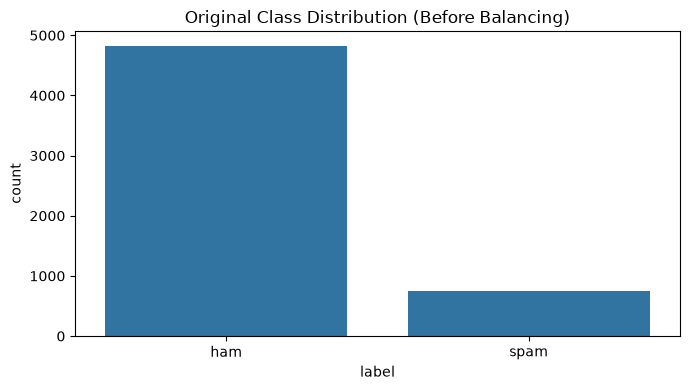


Balanced shape: (1494, 2)


In [90]:
# Cell 10: Show original distribution, then balance classes.

# First: show the original (unbalanced) distribution
print('Original shape:', sms_data.shape)
print(sms_data['label'].value_counts())
plt.figure(figsize=(7, 4))
sns.countplot(x='label', data=sms_data)
plt.title('Original Class Distribution (Before Balancing)')
plt.tight_layout()
plt.show()

# Then: balance by downsampling ham to match spam size
ham_df = sms_data[sms_data['label'] == 'ham']
spam_df = sms_data[sms_data['label'] == 'spam']

if ham_df.empty or spam_df.empty:
    raise ValueError('Both ham and spam classes are required.')

ham_balanced = ham_df.sample(n=len(spam_df), random_state=SEED)
balanced_data = pd.concat([ham_balanced, spam_df], axis=0)
sms_data = balanced_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print('\nBalanced shape:', sms_data.shape)

**Inference:**
- The first chart should look imbalanced because ham is much larger than spam.
- This tells us why balancing is needed before training the model.

## Step 4: Encode Labels into Numbers

What is happening here:
- We convert `ham` into 0.
- We convert `spam` into 1.

Why this step matters:
- Neural networks work with numbers, not words like `ham` and `spam`.

In [91]:
# Cell 12: Add a numeric label column.
valid_labels = set(sms_data['label'].unique())
if not valid_labels.issubset({'ham', 'spam'}):
    raise ValueError(f'Unexpected labels found: {sorted(valid_labels)}')

sms_data['label_enc'] = sms_data['label'].map({'ham': 0, 'spam': 1})
sms_data.head()

,label,text,label_enc
0,spam,"URGENT, IMPORTANT INFORMATION FOR O2 USER. TOD...",1
1,spam,Panasonic & BluetoothHdset FREE. Nokia FREE. M...,1
2,spam,Do you want a new Video handset? 750 any time ...,1
3,spam,Hi if ur lookin 4 saucy daytime fun wiv busty ...,1
4,spam,09066362231 URGENT! Your mobile No 07xxxxxxxxx...,1


## Step 5: Check Class Distribution (After Balancing)

What is happening here:
- We count how many ham and spam messages exist after balancing.
- We draw a simple bar chart to confirm both classes are now equal.

Why this step matters:
- This confirms the classes are now equal, which leads to fairer training.

Balanced shape: (1494, 3)
label
spam    747
ham     747
Name: count, dtype: int64


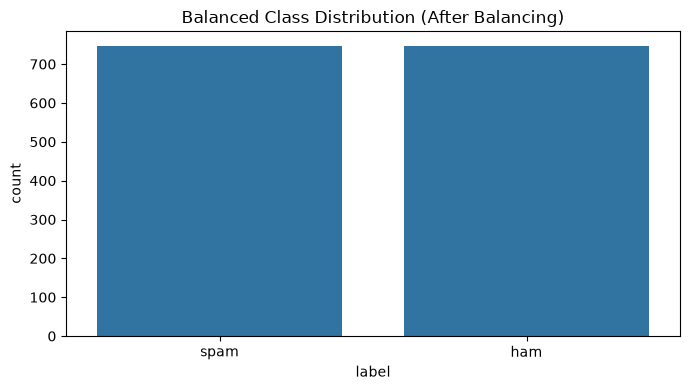

In [92]:
# Cell 14: Plot ham vs spam counts after balancing.
print('Balanced shape:', sms_data.shape)
print(sms_data['label'].value_counts())
plt.figure(figsize=(7, 4))
sns.countplot(x='label', data=sms_data)
plt.title('Balanced Class Distribution (After Balancing)')
plt.tight_layout()
plt.show()

**Inference:**
- The two bars are now equal.
- This confirms the dataset was balanced correctly, so the model will not prefer one class too much.

## Step 6: Clean the SMS Text

What is happening here:
- We lowercase the message.
- We remove punctuation.
- We remove common stop words.

Why this step matters:
- This removes noise.
- The model can focus more on important words.

In [93]:
# Cell 16: Clean SMS messages in small easy steps.
def remove_punctuation(text: str) -> str:
    table = str.maketrans('', '', string.punctuation)
    return str(text).translate(table)

def remove_stop_words(text: str) -> str:
    words = str(text).lower().split()
    words = [word for word in words if word not in STOP_WORDS]
    return ' '.join(words)

cleaned_data = sms_data.copy()
cleaned_data['text'] = cleaned_data['text'].astype(str).str.lower()
cleaned_data['text'] = cleaned_data['text'].apply(remove_punctuation)
cleaned_data['text'] = cleaned_data['text'].apply(remove_stop_words)
cleaned_data.head()

,label,text,label_enc
0,spam,urgent important information o2 user today luc...,1
1,spam,panasonic bluetoothhdset free nokia free motor...,1
2,spam,want new video handset 750 time network mins u...,1
3,spam,hi ur lookin 4 saucy daytime fun wiv busty mar...,1
4,spam,09066362231 urgent mobile 07xxxxxxxxx won ãâ£...,1


## Step 7: Compute Simple Text Statistics

What is happening here:
- We count average words per message.
- We estimate the vocabulary size.

Why this step matters:
- These numbers help us choose a sequence length and vocabulary size.

In [94]:
# Cell 16: Compute a few easy-to-read statistics.
word_counts = cleaned_data['text'].astype(str).apply(lambda value: len(value.split()))
avg_words_len = int(round(word_counts.mean()))
total_words_length = len(set(' '.join(cleaned_data['text'].astype(str)).split()))

print(f'Total messages: {len(cleaned_data)}')
print(f'Average words per message: {avg_words_len}')
print(f'Approximate vocabulary size: {total_words_length}')

Total messages: 1494
Average words per message: 12
Approximate vocabulary size: 4616


## Step 8: Split Data into Train and Test Sets

What is happening here:
- We keep most messages for training.
- We keep some messages for testing.

Why this step matters:
- The test set helps us check whether the model works on unseen messages.

In [95]:
# Cell 18: Split the data into training and testing parts.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    cleaned_data['text'],
    cleaned_data['label_enc'].to_numpy(),
    test_size=0.2,
    random_state=SEED,
    stratify=cleaned_data['label_enc'],
)

print(f'Training messages: {len(X_train_text)}')
print(f'Testing messages: {len(X_test_text)}')

Training messages: 1195
Testing messages: 299


## Step 9: Tokenize and Pad the Messages

What is happening here:
- We convert words into numbers.
- We make all message lengths equal by padding with zeros.

Why this step matters:
- Neural networks cannot read raw text directly.

In [96]:
# Cell 20: Convert SMS messages into equal-length number sequences.
MAX_WORDS = 12000
MAX_LEN = 25

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text.tolist())

X_train_seq = tokenizer.texts_to_sequences(X_train_text.tolist())
X_test_seq = tokenizer.texts_to_sequences(X_test_text.tolist())

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('Train tensor shape:', X_train_pad.shape)
print('Test tensor shape :', X_test_pad.shape)

Train tensor shape: (1195, 25)
Test tensor shape : (299, 25)


## Step 10: Build a Very Simple LSTM Model

What is happening here:
- We use an Embedding layer to learn word meaning.
- We use one LSTM layer to understand sequence order.
- We use a small Dense layer before the final output.

Why this step matters:
- This model is simple enough for beginners and still useful.

In [97]:
# Cell 22: Build a small easy-to-understand LSTM model.
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build((None, MAX_LEN))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 25, 32)         │       129,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,153 (520.13 KB)

 Trainable params: 133,153 (520.13 KB)

 Non-trainable params: 0 (0.00 B)

## Step 11: Train the Model

What is happening here:
- We train for a few epochs.
- We stop early if validation accuracy stops improving.

Why this step matters:
- This helps prevent unnecessary training and reduces overfitting.

In [98]:
# Cell 24: Train the model with simple callbacks.
early_stop = EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

Epoch 1/10


E0000 00:00:1787132351.166088  546366 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6435 - loss: 0.6635 - val_accuracy: 0.9030 - val_loss: 0.5521 - learning_rate: 0.0010
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.2880 - val_accuracy: 0.9465 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9816 - loss: 0.1001 - val_accuracy: 0.9465 - val_loss: 0.1771 - learning_rate: 0.0010
Epoch 4/10
28/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9833 - loss: 0.0898
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9808 - loss: 0.0982 - val_accuracy: 0.9197 - val_loss: 0.3035 - learning_rate: 0.0010


## Step 12: Evaluate the Model

What is happening here:
- We measure test loss and test accuracy.
- We also measure precision, recall, and F1-score.

Why this step matters:
- Accuracy alone is not enough, especially for spam detection.

In [99]:
# Cell 26: Evaluate using multiple easy metrics.
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
probs = model.predict(X_test_pad, verbose=0).ravel()
preds = (probs >= 0.5).astype(int)

precision = precision_score(y_test, preds, zero_division=0)
recall = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, preds, target_names=['ham', 'spam'], zero_division=0))

Test Loss: 0.1856
Test Accuracy: 0.9465
Precision: 0.9650
Recall: 0.9262
F1-score: 0.9452

Classification Report:
              precision    recall  f1-score   support

         ham       0.93      0.97      0.95       150
        spam       0.97      0.93      0.95       149

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



**Inference:**
- Precision, recall, and F1-score help us judge spam detection better than accuracy alone.
- If recall is lower, the model is missing more spam messages.
- If precision is lower, the model is wrongly marking ham as spam more often.

## Step 13: Visualize Model Performance Metrics

What is happening here:
- We build a results table with accuracy, precision, recall, and F1-score.
- We plot a bar chart to compare the four metrics side by side.
- We plot a line graph to see the performance trend across metrics.

Why this step matters:
- A single number (accuracy) can be misleading. These charts give the full picture at a glance.

Model Performance Summary:
            accuracy  precision  recall  f1-score
LSTM Model    0.9465      0.965  0.9262    0.9452


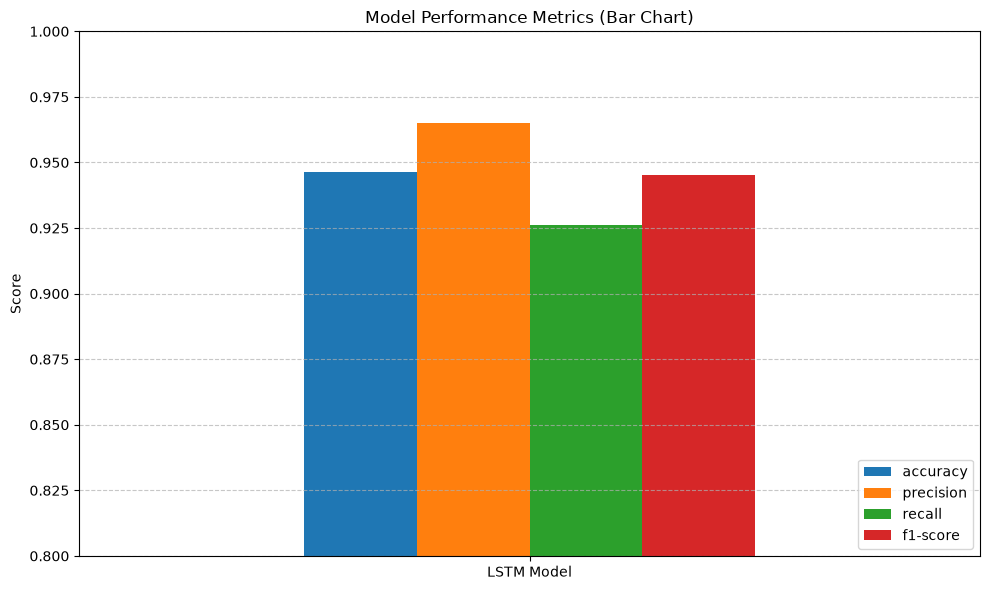

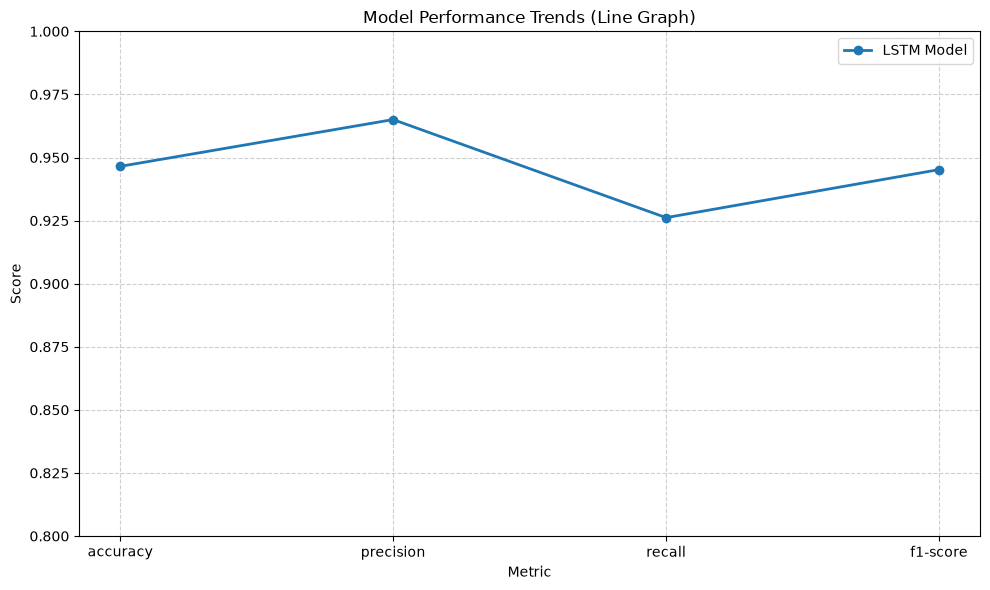

In [100]:
# Cell 28: Visualize LSTM model performance as bar chart and line graph.
import pandas as pd

# Build a results table with the metrics from Step 11
results_df = pd.DataFrame(
    {'accuracy': [test_acc], 'precision': [precision], 'recall': [recall], 'f1-score': [f1]},
    index=['LSTM Model'],
)

print('Model Performance Summary:')
print(results_df.round(4))

# a. Bar Chart
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Metrics (Bar Chart)')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# b. Line Graph
plt.figure(figsize=(10, 6))
for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2,
    )
plt.title('Model Performance Trends (Line Graph)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**Inference:**
- The bar chart makes the metric values easy to compare side by side.
- The line graph shows which metric is strongest and which one needs improvement.

## Step 14: Plot the Confusion Matrix

What is happening here:
- We compare actual and predicted labels in a heatmap.

Why this step matters:
- It shows exactly where the model made mistakes.

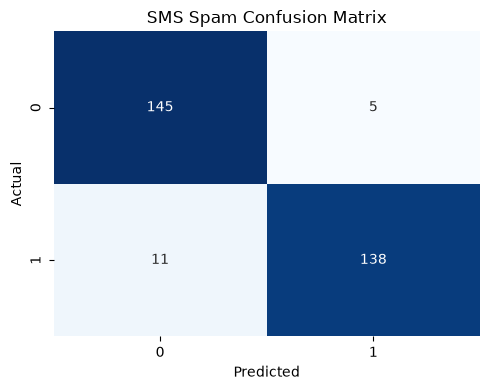

In [101]:
# Cell 30: Plot the confusion matrix.
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SMS Spam Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Inference:**
- 145 means ham was predicted correctly.
- 138 means spam was predicted correctly.
- 5 means ham was wrongly predicted as spam.
- 11 means spam was wrongly predicted as ham.

**What this tells us:**
- The model is doing well overall.
- It is slightly better at detecting ham than spam.
- The main error is missing some spam messages.

**Simple conclusion:**
- This is a good result for a beginner SMS spam detector.

**Inference:**
- The confusion matrix shows correct predictions on the diagonal.
- The off-diagonal numbers are the mistakes.
- Here, the model is doing well, but it still misses some spam and marks a few ham messages incorrectly.

## Step 15: Plot Training Curves

What is happening here:
- We plot accuracy and loss over epochs.

Why this step matters:
- These charts help us see whether the model improved properly.

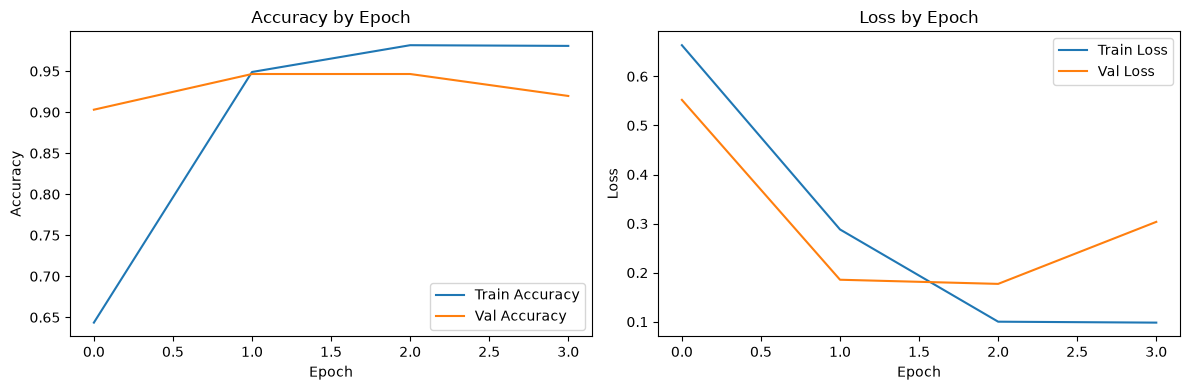

In [102]:
# Cell 32: Plot training and validation curves.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history.get('accuracy', []), label='Train Accuracy')
axes[0].plot(history.history.get('val_accuracy', []), label='Val Accuracy')
axes[0].set_title('Accuracy by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history.get('loss', []), label='Train Loss')
axes[1].plot(history.history.get('val_loss', []), label='Val Loss')
axes[1].set_title('Loss by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

**Inference:**
- If training and validation curves stay close, the model is learning in a healthy way.
- If validation loss rises while training loss falls, that would mean overfitting.

## Step 16: Visualize Common Words

What is happening here:
- We draw one word cloud for ham.
- We draw one word cloud for spam.

Why this step matters:
- This makes the dataset easier to understand visually.

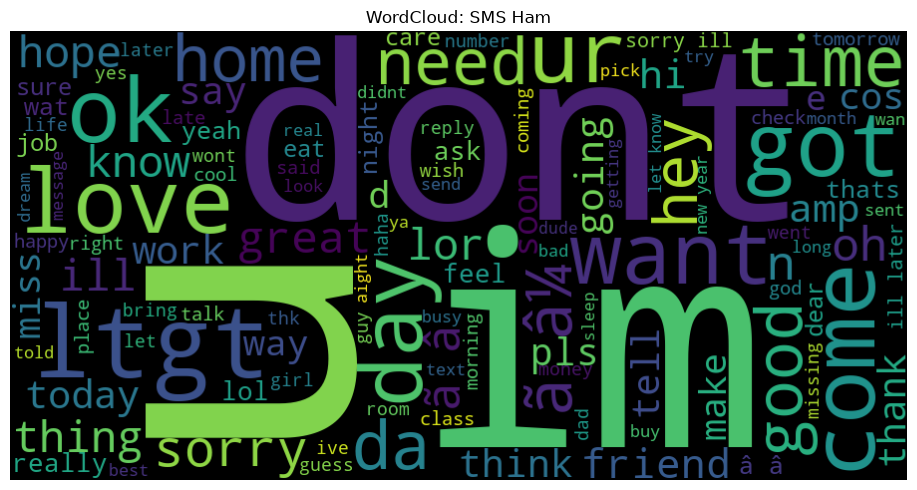

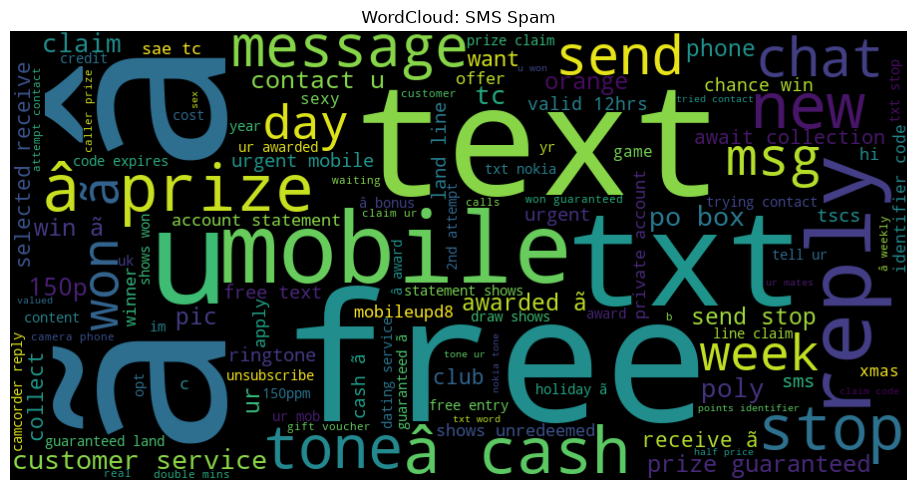

In [103]:
# Cell 34: Draw word clouds for ham and spam SMS messages.
def plot_wordcloud(df: pd.DataFrame, label_name: str, title: str) -> None:
    text_blob = ' '.join(df[df['label'] == label_name]['text'].astype(str).tolist())
    if not text_blob.strip():
        print(f'No messages found for label: {label_name}')
        return
    wc = WordCloud(background_color='black', width=900, height=450, max_words=120).generate(text_blob)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_wordcloud(cleaned_data, 'ham', 'WordCloud: SMS Ham')
plot_wordcloud(cleaned_data, 'spam', 'WordCloud: SMS Spam')

**Inference:**
- The word clouds show which words appear most often in ham and spam.
- Frequent spam words can help explain why the model learns to detect spam messages.

## Step 17: Save the Model and Metrics

What is happening here:
- We save the trained model.
- We save the main evaluation numbers to a text file.

Why this step matters:
- You can reuse the model later without retraining.

In [104]:
# Cell 36: Save the SMS model and metrics.
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
artifacts = project_root / 'artifacts'
(artifacts / 'models').mkdir(parents=True, exist_ok=True)
(artifacts / 'reports').mkdir(parents=True, exist_ok=True)

model_path = artifacts / 'models' / 'spam_sms_lstm_from_notebook.keras'
metrics_path = artifacts / 'reports' / 'spam_sms_metrics_from_notebook.txt'

model.save(model_path)
metrics_path.write_text(
    f'test_loss: {test_loss:.4f}\n'
    f'test_accuracy: {test_acc:.4f}\n'
    f'precision: {precision:.4f}\n'
    f'recall: {recall:.4f}\n'
    f'f1_score: {f1:.4f}\n',
    encoding='utf-8',
)

print(f'Model saved to: {model_path}')
print(f'Metrics saved to: {metrics_path}')

Model saved to: /Users/bti-001541/machine-learning-project/artifacts/models/spam_sms_lstm_from_notebook.keras
Metrics saved to: /Users/bti-001541/machine-learning-project/artifacts/reports/spam_sms_metrics_from_notebook.txt


## Summary: Complete SMS Model Flow (From Start to Finish)

### **What Did We Build?**
We built a **Spam SMS Detector** that learns to identify whether a text message is spam or ham using a simple LSTM neural network.

---

### **FLOW MATRIX: How the Model Works (Step by Step)**

#### **STAGE 1: DATA INPUT** 📩
```
Raw SMS CSV File
↓
Step 1: Load CSV → raw_data (v1, v2 columns)
Step 2: Rename columns → label, text
Step 3: Balance dataset → equal ham and spam rows
Step 4: Encode labels → ham=0, spam=1
Step 5: Check class distribution (bar chart)
```

#### **STAGE 2: TEXT CLEANING** 🧹
```
Raw Text → lowercase, remove punctuation, remove stop words
↓
Step 6: Clean SMS Text
"WIN a free prize now! Click here!!!"
↓
"win free prize click"
```

#### **STAGE 3: TEXT STATISTICS** 📊
```
Step 7: Compute text statistics
↓
Average words per message
Approximate vocabulary size
→ Helps choose MAX_LEN and MAX_WORDS
```

#### **STAGE 4: CONVERTING TEXT TO NUMBERS** 🔢
```
Step 8: Train / Test Split → 80% train, 20% test
Step 9: Tokenize and Pad
↓
Words → Tokenizer converts words into numbers
"win"   → 45
"free"  → 18
"prize" → 92
"click" → 11
↓
[45, 18, 92, 11]
Pad to MAX_LEN = 25
↓
[45, 18, 92, 11, 0, 0, 0, ..., 0]
```

#### **STAGE 5: MODEL PROCESSING** 🧠

**Step 10 — Build LSTM Model**

**Layer 1 - EMBEDDING**
```
Numbers → Meaning vectors
[45, 18, 92, 11]
↓ EMBEDDING (output_dim=32)
[[0.1, 0.4, ...], [0.2, 0.5, ...], ...]
```

**Layer 2 - LSTM**
```
Reads the message in order
↓
"win" → "free" → "prize" → "click"
↓
Learns the pattern of spam words together
```

**Layer 3 - DENSE (relu)**
```
Learns final small patterns from the LSTM output
↓
Helps make the last decision
```

**Layer 4 - SIGMOID OUTPUT**
```
One number between 0 and 1
↓
- close to 0 = HAM 🟢
- close to 1 = SPAM 🔴
```

---

#### **STAGE 6: MODEL TRAINING** 👨‍🏫
```
Step 11: Train the model
↓
1. Show SMS messages to the model
2. Model guesses: spam or ham
3. Compare guess with real label
4. Change weights to improve
5. EarlyStopping stops if no improvement after 2 epochs
6. ReduceLROnPlateau slows learning if loss stalls
```

#### **STAGE 7: TESTING & EVALUATION** ✅
```
Step 12: Evaluate the Model
↓
Test messages (not seen during training)
↓
Model predicts spam or ham
↓
Get loss, accuracy, precision, recall, and F1-score
↓
Step 13: Visualize metrics → Bar Chart + Line Graph
Step 14: Confusion Matrix → see exact mistakes
Step 15: Training Curves → accuracy and loss per epoch
Step 16: Word Clouds → most common ham and spam words
```

#### **STAGE 8: SAVE MODEL** 💾
```
Step 17: Save the Model and Metrics
↓
Save as: "spam_sms_lstm_from_notebook.keras"
↓
Use later without retraining
```

---

### **THE BIG PICTURE: Complete Journey** 🗺️
```
📩 Raw CSV
   ↓  Step 1–2: Load & clean table
🔀 Step 3: Balance classes
🔢 Step 4: Encode labels ham→0, spam→1
📊 Step 5: Check class distribution
🧹 Step 6: Clean SMS text
📈 Step 7: Text statistics
✂️  Step 8: Train / test split
🔡 Step 9: Tokenize + pad
🏗️  Step 10: Build LSTM model
🏋️  Step 11: Train model
📉 Step 12: Evaluate metrics
📊 Step 13: Bar chart + line graph
🗺️  Step 14: Confusion matrix
📈 Step 15: Training curves
☁️  Step 16: Word clouds
💾 Step 17: Save model + metrics
   ↓
✅ RESULT: "SPAM" 🔴 or "HAM" 🟢
```

---

### **Simple Analogy for Children** 👶
```
Imagine learning to spot a bad candy packet:

1. You collect packets (load data)
2. You make sure equal good and bad ones (balance)
3. You look at the words on it (clean text)
4. You remember which ones were bad before (train)
5. Next time you see a similar packet, you guess better (predict)
6. That is what this SMS model does with messages
```

---

### **Why LSTM Works Best for This** 🎯
- SMS messages are short sequences
- Word order still matters (spam words appear together)
- LSTM remembers nearby context in the message
- It is simple enough for beginners to understand

---

### **What We Saved** 💾
- Model file: `artifacts/models/spam_sms_lstm_from_notebook.keras`
- Metrics file: `artifacts/reports/spam_sms_metrics_from_notebook.txt`
- You can use these later without retraining

---

### **Final Learning Summary** 🎓
You just built a 17-step machine learning pipeline that:
1. Loads and cleans a raw SMS dataset
2. Balances the classes so training is fair
3. Encodes, cleans, and tokenizes the text
4. Trains a simple LSTM model to detect spam
5. Evaluates with 5 metrics and 4 visualizations
6. Saves the trained model for later use